In [69]:
import pandas as pd
import numpy as np
import time
import shap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

In [70]:
# loading the data from CSV file to a Pandas Dataframe
calories = pd.read_csv('calories.csv')
calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [71]:
exercise_data = pd.read_csv('exercise.csv')
exercise_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [72]:
# combining the two datas
calories_data = pd.concat([exercise_data, calories['Calories']], axis = 1)
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [73]:
calories_data = calories_data.drop(columns = ['User_ID'], axis = 1)

In [74]:
calories_data.shape

(15000, 8)

In [75]:
calories_data.replace({'Gender' :{'male' :0, 'female' :1}}, inplace = True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_3088\3984358361.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  calories_data.replace({'Gender' :{'male' :0, 'female' :1}}, inplace = True)


In [76]:
X = calories_data.drop(columns = ['Calories'], axis = 1)
Y = calories_data['Calories']

In [77]:
X_train, X_test, Y_train, Y_test =  train_test_split(X, Y, test_size = 0.2)

In [78]:
X_train.shape
X_test.shape

(3000, 7)

C:\Users\DELL\AppData\Local\Temp\ipykernel_3088\1803947723.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')


Correlation of features with 'Calories':
Duration      0.955421
Heart_Rate    0.897882
Body_Temp     0.824558
Age           0.154395
Weight        0.035481
Height        0.017537
Gender       -0.022357
Name: Calories, dtype: float64


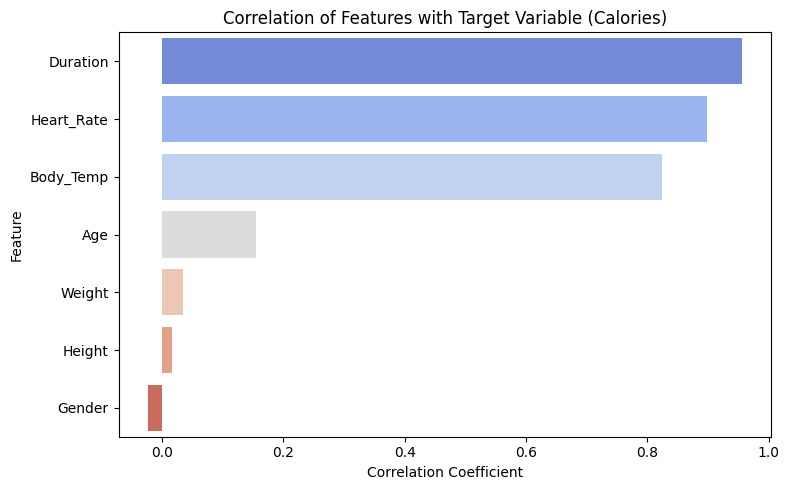

In [79]:
# Calculate correlation matrix
corr_matrix = calories_data.corr()

# Extract correlations with the target variable 'Calories'
target_corr = corr_matrix['Calories'].drop('Calories').sort_values(ascending=False)

# Display top features
print("Correlation of features with 'Calories':")
print(target_corr)

# Plot correlation with Calories
plt.figure(figsize=(8, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')
plt.title("Correlation of Features with Target Variable (Calories)")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [80]:
# 1. Initialize the results list
results = []

# 2. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)
Y_train_pred_lr = lr_model.predict(X_train)
Y_test_pred_lr = lr_model.predict(X_test)

results.append({
    "Model": "Linear Regression",
    "Train MAE": mean_absolute_error(Y_train, Y_train_pred_lr),
    "Test MAE": mean_absolute_error(Y_test, Y_test_pred_lr),
    "Train R2": r2_score(Y_train, Y_train_pred_lr),
    "Test R2": r2_score(Y_test, Y_test_pred_lr)
})

In [81]:
# 3. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=20)
rf_model.fit(X_train, Y_train)
Y_train_pred_rf = rf_model.predict(X_train)
Y_test_pred_rf = rf_model.predict(X_test)

results.append({
    "Model": "Random Forest",
    "Train MAE": mean_absolute_error(Y_train, Y_train_pred_rf),
    "Test MAE": mean_absolute_error(Y_test, Y_test_pred_rf),
    "Train R2": r2_score(Y_train, Y_train_pred_rf),
    "Test R2": r2_score(Y_test, Y_test_pred_rf)
})

In [82]:
# 4. XGBoost
xgb_model = XGBRegressor(n_estimators=100, max_depth=20, learning_rate=0.5, objective='reg:squarederror')
xgb_model.fit(X_train, Y_train)
Y_train_pred_xgb = xgb_model.predict(X_train)
Y_test_pred_xgb = xgb_model.predict(X_test)

results.append({
    "Model": "XGBoost",
    "Train MAE": mean_absolute_error(Y_train, Y_train_pred_xgb),
    "Test MAE": mean_absolute_error(Y_test, Y_test_pred_xgb),
    "Train R2": r2_score(Y_train, Y_train_pred_xgb),
    "Test R2": r2_score(Y_test, Y_test_pred_xgb)
})

In [83]:
# 5. LightGBM
lgbm_model = LGBMRegressor(n_estimators=100, max_depth=20, learning_rate=0.5)
lgbm_model.fit(X_train, Y_train)
Y_train_pred_lgbm = lgbm_model.predict(X_train)
Y_test_pred_lgbm = lgbm_model.predict(X_test)

results.append({
    "Model": "LGBM",
    "Train MAE": mean_absolute_error(Y_train, Y_train_pred_lgbm),
    "Test MAE": mean_absolute_error(Y_test, Y_test_pred_lgbm),
    "Train R2": r2_score(Y_train, Y_train_pred_lgbm),
    "Test R2": r2_score(Y_test, Y_test_pred_lgbm)
})

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001242 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 365
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 7
[LightGBM] [Info] Start training from score 89.607417


In [84]:
# 6. K-Nearest Neighbors
knn_model = KNeighborsRegressor(n_neighbors=5, weights='uniform')
knn_model.fit(X_train, Y_train)
Y_train_pred_knn = knn_model.predict(X_train)
Y_test_pred_knn = knn_model.predict(X_test)

results.append({
    "Model": "KNN",
    "Train MAE": mean_absolute_error(Y_train, Y_train_pred_knn),
    "Test MAE": mean_absolute_error(Y_test, Y_test_pred_knn),
    "Train R2": r2_score(Y_train, Y_train_pred_knn),
    "Test R2": r2_score(Y_test, Y_test_pred_knn)
})

In [91]:
# Results Summary
df_results = pd.DataFrame(results)
print("\n Model Performance Summary:")
print(df_results)


 Model Performance Summary:
               Model  Train MAE  Test MAE  Train R2   Test R2
0  Linear Regression   8.391869  8.214485  0.967018  0.967931
1      Random Forest   0.693353  1.808386  0.999679  0.997981
2            XGBoost   0.000669  2.235183  1.000000  0.997124
3               LGBM   1.011298  1.572446  0.999524  0.998656
4                KNN   4.250300  5.036467  0.990828  0.987330


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000626 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 365
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 7
[LightGBM] [Info] Start training from score 89.607417


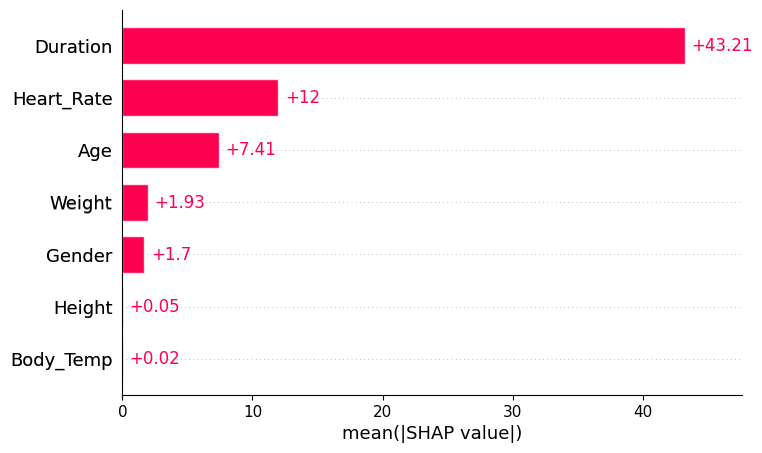

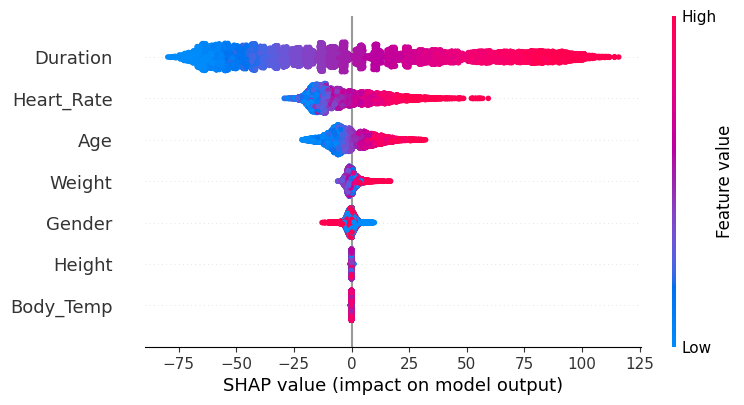

In [90]:
# Fit the final model (if not already done)
final_model = LGBMRegressor()
final_model.fit(X_train, Y_train)

# Use SHAP TreeExplainer for tree-based models like LGBM
explainer = shap.Explainer(final_model)
shap_values = explainer(X_train)

# Plot feature importance (global explanation)
plt.figure(figsize=(8, 10))
shap.plots.bar(shap_values)

# Beeswarm plot for detailed distribution
plt.figure(figsize=(8, 10))
shap.plots.beeswarm(shap_values)

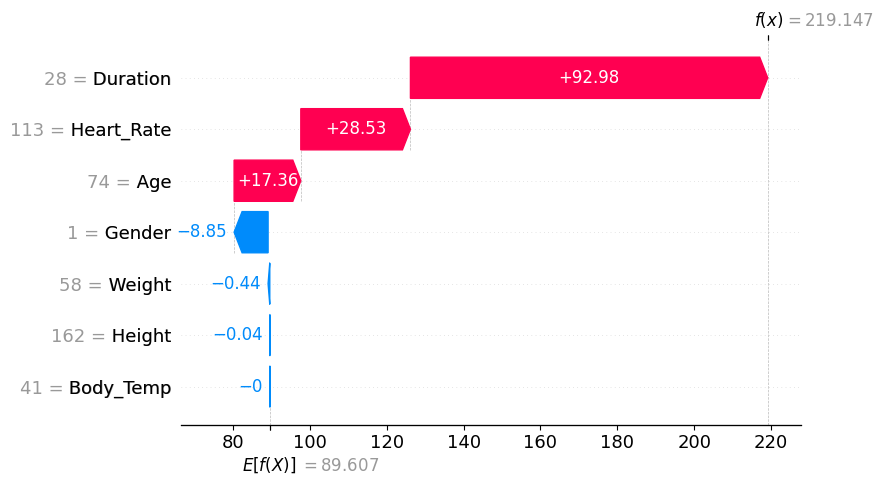

In [93]:
#Impact on Features on Final Output for 1 instance

instance_index = 0
instance = X_test.iloc[[instance_index]]

shap_value_single = explainer(instance)

shap.plots.force(shap_value_single)

shap.plots.waterfall(shap_value_single[0])

In [98]:
# Average predictions
Y_test_pred_avg = (Y_test_pred_xgb + Y_test_pred_lgbm) / 2
# Evaluate average predictions
test_mae_avg = mean_absolute_error(Y_test, Y_test_pred_avg)
test_r2_avg = r2_score(Y_test, Y_test_pred_avg)

print(f"🔹 Test MAE (Avg): {test_mae_avg:.4f}")
print(f"🔹 Test R² (Avg): {test_r2_avg:.4f}")

Y_train_pred_avg = (Y_train_pred_xgb + Y_train_pred_lgbm) / 2

train_mae_avg = mean_absolute_error(Y_train, Y_train_pred_avg)
train_r2_avg = r2_score(Y_train, Y_train_pred_avg)

print(f"🔹 Train MAE (Avg): {train_mae_avg:.4f}")
print(f"🔹 Train R² (Avg): {train_r2_avg:.4f}")

🔹 Test MAE (Avg): 1.4741
🔹 Test R² (Avg): 0.9988
🔹 Train MAE (Avg): 0.5057
🔹 Train R² (Avg): 0.9999


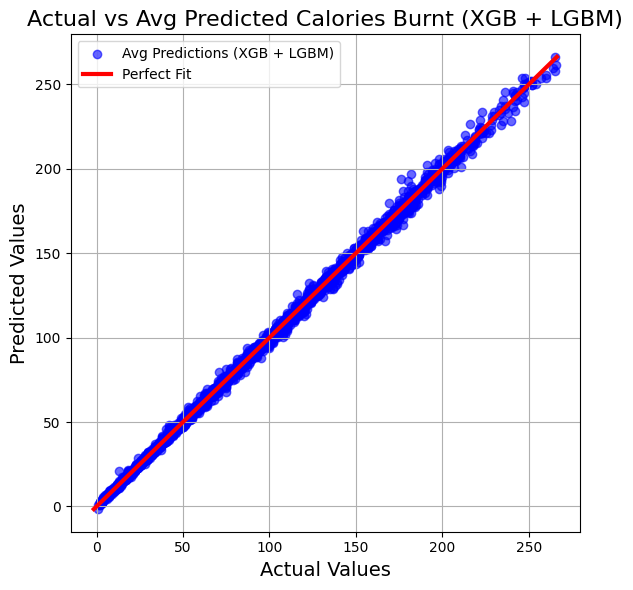

In [99]:
# Plotting
plt.figure(figsize=(6,6))
plt.scatter(Y_test, Y_test_pred_avg, color='blue', label='Avg Predictions (XGB + LGBM)', alpha=0.6)

lims = [min(Y_test.min(), Y_test_pred_avg.min()), max(Y_test.max(), Y_test_pred_avg.max())]
plt.plot(lims, lims, color='red', linewidth=3, label='Perfect Fit')

plt.xlabel('Actual Values', fontsize=14)
plt.ylabel('Predicted Values', fontsize=14)
plt.title('Actual vs Avg Predicted Calories Burnt (XGB + LGBM)', fontsize=16)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [92]:
# --- Manual Prediction ---
print("\n Manual Input for Calorie Prediction")

# Collect inputs (you can replace input() with fixed values during testing)
manual_input = {
    'Gender': int(input("Gender (0 for Male, 1 for Female): ")),
    'Age': int(input("Age: ")),
    'Height': float(input("Height (in cm): ")),
    'Weight': float(input("Weight (in kg): ")),
    'Duration': float(input("Exercise Duration (in minutes): ")),
    'Heart_Rate': float(input("Heart Rate: ")),
    'Body_Temp': float(input("Body Temperature (in °C): "))
}

# Convert to DataFrame
input_df = pd.DataFrame([manual_input])

# Preprocess the input data if needed (scaling or encoding)
# Example: if you've used scaling during training, apply the same scaling here
# input_df_scaled = scaler.transform(input_df)  # Uncomment if using scaling

# Use both models (XGBoost and LGBM) to predict
xgb_pred = models["XGBoost"].predict(input_df)  # Predict using XGBoost
lgbm_pred = models["LGBM"].predict(input_df)  # Predict using LGBM

# Calculate the average prediction from XGBoost and LGBM
avg_pred = (xgb_pred + lgbm_pred) / 2

# Output the averaged prediction
print(f"\nEstimated Calories Burned (Averaging Ensemble): {avg_pred[0]:.2f} Cal")


 Manual Input for Calorie Prediction


Gender (0 for Male, 1 for Female):  0
Age:  68
Height (in cm):  190
Weight (in kg):  94
Exercise Duration (in minutes):  29
Heart Rate:  105
Body Temperature (in °C):  40.8



Estimated Calories Burned (Averaging Ensemble): 231.55 Cal
